SHAPE de 2019-1 ate 2021-1  (269110, 69)
SHAPE de apenas 2021-2 (55543, 69)
------------------------------------------------------------
total de linhas de 2019-1 ate 2021-1 


,situacao_fies,qtde_inscritos
0,CONTRATADA,6622
1,INSCRIÇÃO POSTERGADA,141
2,LISTA DE ESPERA,236930
3,NÃO CONTRATADO,14596
4,OPÇÃO NÃO CONTRATADA,2669
5,PARTICIPACAO CANCELADA PELO CANDIDATO,7519
6,PRÉ-SELECIONADO,196
7,REJEITADA PELA CPSA,437


------------------------------------------------------------
total de linhas de apenas 2021-2


,situacao_fies,qtde_inscritos
0,CONTRATADA,693
1,INSCRIÇÃO POSTERGADA,239
2,LISTA DE ESPERA,50654
3,NÃO CONTRATADO,1835
4,OPÇÃO NÃO CONTRATADA,202
5,PARTICIPACAO CANCELADA PELO CANDIDATO,1351
6,PRÉ-SELECIONADO,413
7,REJEITADA PELA CPSA,156


--- Quantidade de NaNs por coluna ---
renda_per_capita                                                                                                             0
gap                                                                                                                          1
idade                                                                                                                        0
nota_corte_gp                                                                                                                0
renda_gap                                                                                                                    1
beneficiado_creduc_fies_NÃO                                                                                                  0
beneficiado_creduc_fies_SIM                                                                                                  0
modalidade_fies_Modalidade II                                            

total_inscritos
ano  semestre subarea_conhecimento_MEDICINA                 
2019 1        True                                      4627
     2        True                                      2530
2020 1        True                                      5286
     2        True                                      2672
2021 1        True                                      6102

/home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


--- Treinamento Concluído ---
Modelo salvo em: /home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/reports/models/analise_016_modelo_fies_logistica.pkl
Shape de X nesta analise:  (21217, 68)


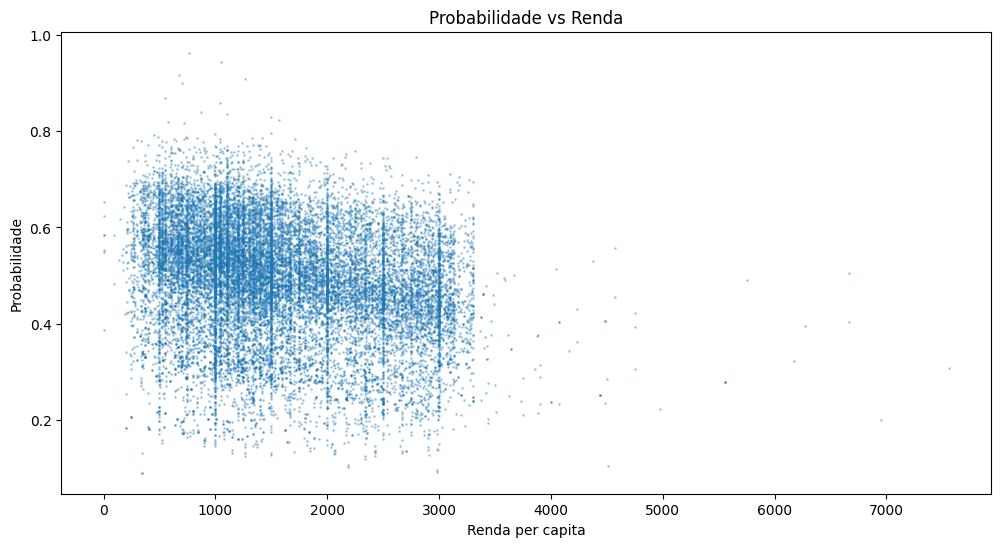

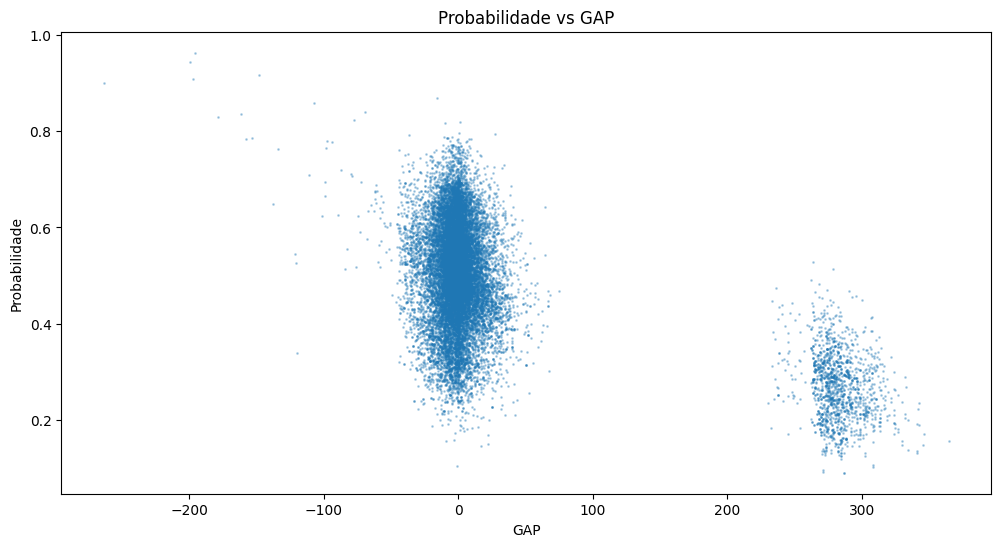

21,217 registros processados.
Top 20 variáveis mais importantes:


,Variável,Coeficiente,Impacto_Absoluto
1,gap,-0.544995,0.544995
3,nota_corte_gp,-0.344740,0.344740
11,conceito_curso_gp_4,-0.249250,0.249250
67,ensino_medio_escola_publica_SIM,-0.248259,0.248259
57,natureza_juridica_mantenedora_PRIVADA COM FINS...,0.231441,0.231441
13,conceito_curso_gp_AUTORIZADO,-0.151201,0.151201
58,natureza_juridica_mantenedora_PRIVADA SEM FINS...,0.136401,0.136401
49,regiao_morar_Sudeste,-0.127847,0.127847
0,renda_per_capita,-0.126499,0.126499
2,idade,0.090287,0.090287


coeficente renda_gap -0.004848218088761757
----- Efeito da RENDA dependendo do GAP -----
GAP -1: efeito da renda = -0.12165092503722885
GAP 0: efeito da renda = -0.12649914312599062
GAP 1: efeito da renda = -0.13134736121475238
----- Efeito do GAP dependendo da RENDA -----
RENDA -1: efeito do gap = -0.5401472135049661
RENDA 0: efeito do gap = -0.5449954315937279
RENDA 1: efeito do gap = -0.5498436496824897


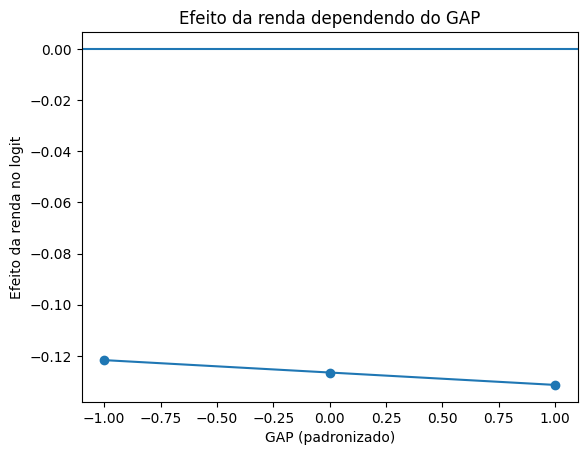

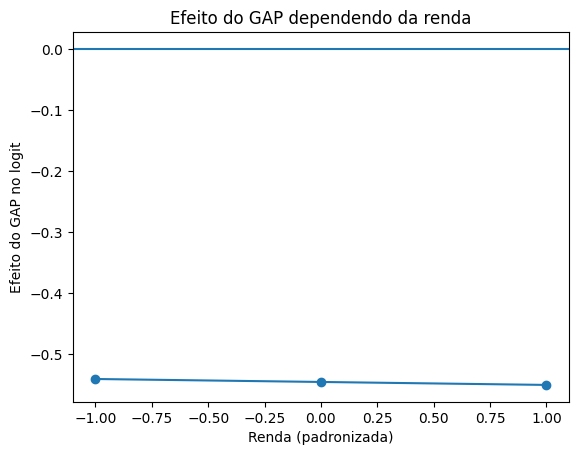

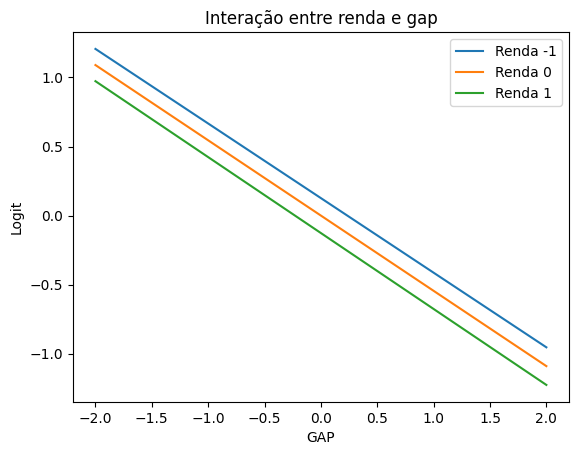

[0.95210367 0.95176621 0.95142649 0.9520963  0.95175878 0.95141901
 0.95208893 0.95175136 0.95141154]


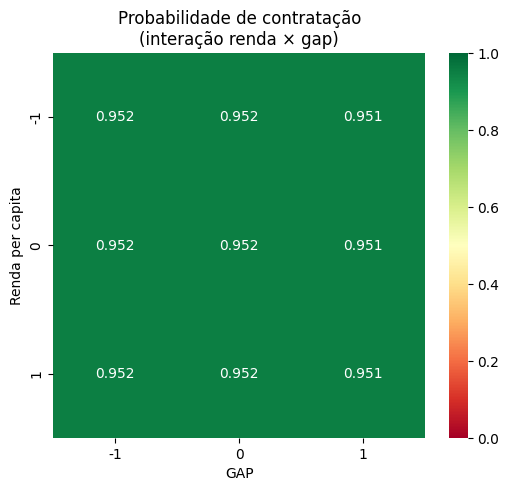

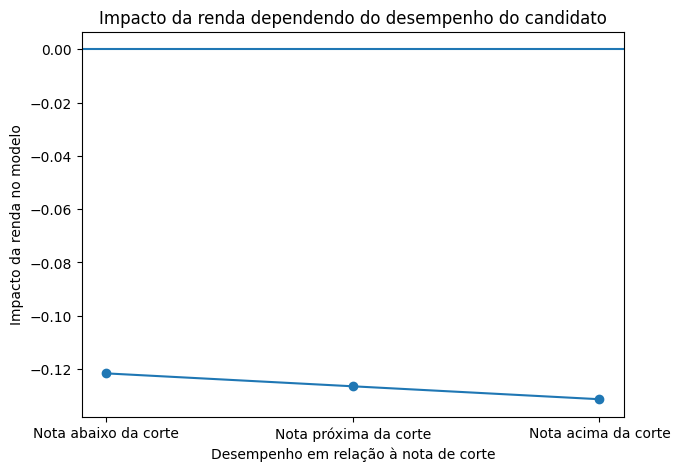

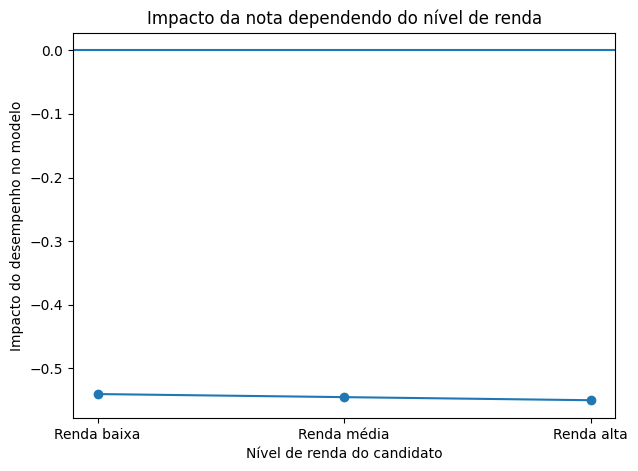

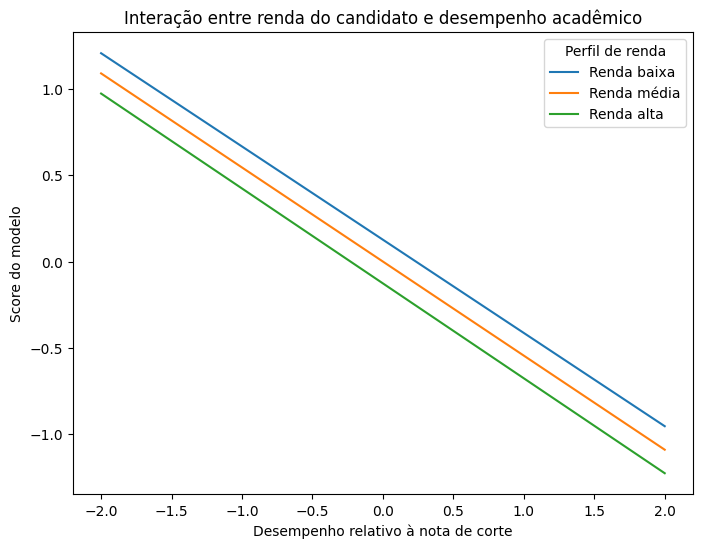

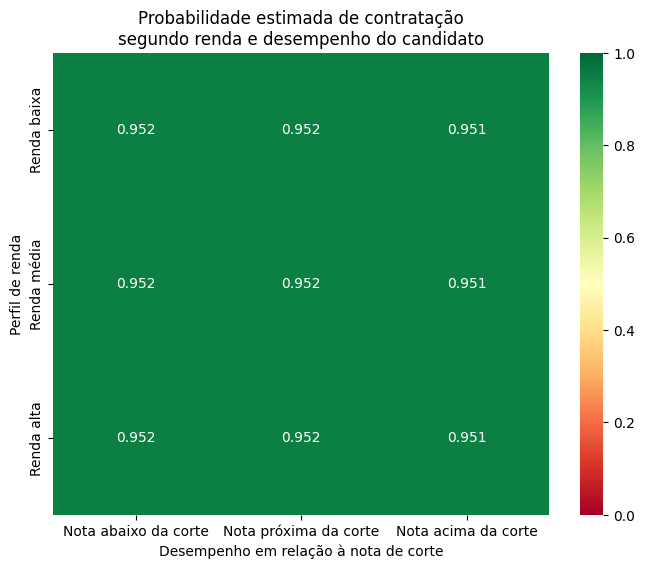

ROC-AUC: 0.6315
Acurácia (threshold ótimo): 0.5543
Threshold ótimo: 0.4787


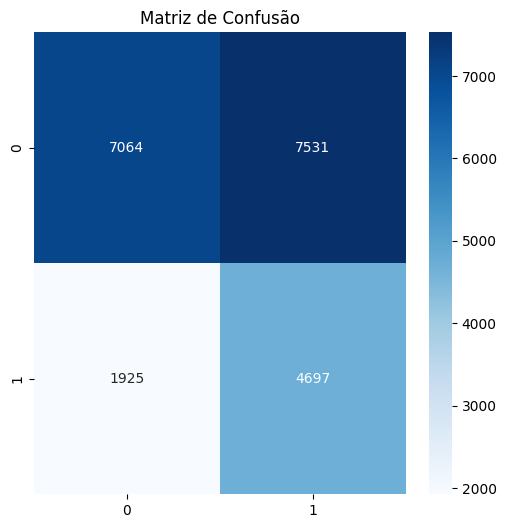

In [ ]:
import sys
import pandas as pd
from src.staging import staging_fies, staging_inep
from src.transform_layer_1 import transform_inscritos, transform_ofertas, transform_inep, verificar_colunas_inep
from src.transform_layer_2 import tratar_nans_cine_inscritos, tratar_nans_cine_ofertas
from src.trasnform_layer_3 import processar_modalidades_e_peneira
from src.load import load_inscritos,load_ofertas,auditoria_inscritos_carregados,auditoria_ofertas_carregadas,exportar_para_sqlite
from src.analise_001 import gerar_dataset_candidatos_unicos_por_Prioridade_inicial
from src.analise_002 import eda_gerar_dataset_com_varias_analises
from src.analise_003 import eda_gerar_funil_de_selecao_6_etapas
from src.analise_004 import analise_fuga_cerebros_de_regioes
from src.analise_005 import verificar_qtde_inscritos_por_ano_e_semestre_nacional_e_regional
from src.analise_006 import gerar_dataset_e_grafico_heatmap_quem_sao_os_inscritos_contratados
from src.analise_007 import orquestrador_inicial_inscritos, orquestrador_ja_rodado_inscritos
from src.analise_008 import orquestrador_inicial_candidatos, orquestrador_ja_rodado_candidatos
from src.analise_009 import orquestrador_inicial_inscritos_nove, orquestrador_ja_rodado_inscritos_nove
from src.analise_009_1 import orquestrador_inicial_inscritos_nove_um, orquestrador_ja_rodado_inscritos_nove_um
from src.analise_010 import orquestrador_inicial_inscritos_dez, orquestrador_ja_rodado_inscritos_dez
from src.analise_011 import orquestrador_analise_011
from src.analise_013 import orquestrador_inicial_inscritos_13,orquestrador_ja_rodado_inscritos_13
from src.analise_014 import orquestrador_inicial_inscritos_14,orquestrador_ja_rodado_inscritos_14
from src.analise_015 import orquestrador_inicial_inscritos_15,orquestrador_ja_rodado_inscritos_15
from src.analise_016 import orquestrador_inicial_inscritos_16,orquestrador_ja_rodado_inscritos_16










comando = 'analise'
etapa = '16'

# --- CAMADA: STAGING ---
if comando == "staging":
    staging_fies()
    staging_inep()

# --- CAMADA: TRANSFORM ---
elif comando == "transform":

    if etapa == "1":
        transform_inep()
    elif etapa == "2":
        transform_inscritos()
    elif etapa == "3":
        transform_ofertas()
    elif etapa == "4":
        verificar_colunas_inep()
    elif etapa == "5":
        tratar_nans_cine_inscritos()
    elif etapa == "6":
        tratar_nans_cine_ofertas()
    elif etapa == "7":
        processar_modalidades_e_peneira()
    elif etapa == "all":
        transform_inep()
        transform_inscritos()
        transform_ofertas()
        verificar_colunas_inep()
        tratar_nans_cine_inscritos()
        tratar_nans_cine_ofertas()
        processar_modalidades_e_peneira()

elif comando == "load":

    load_inscritos()
    load_ofertas()
    auditoria_inscritos_carregados()
    auditoria_ofertas_carregadas()
    exportar_para_sqlite()

elif comando == 'analise':

    if etapa == "1":
        gerar_dataset_candidatos_unicos_por_Prioridade_inicial()

    elif etapa == "2":
        eda_gerar_dataset_com_varias_analises()

    elif etapa == "3":
        eda_gerar_funil_de_selecao_6_etapas()

    elif etapa == "4":
        analise_fuga_cerebros_de_regioes()

    elif etapa == "5":
        verificar_qtde_inscritos_por_ano_e_semestre_nacional_e_regional()

    elif etapa == "6":
        gerar_dataset_e_grafico_heatmap_quem_sao_os_inscritos_contratados()

    elif etapa == "7":
        orquestrador_inicial_inscritos()
    
    elif etapa == "7.1":
        orquestrador_ja_rodado_inscritos()

    elif etapa == "8":
        orquestrador_inicial_candidatos()
    
    elif etapa == "8.1":
        orquestrador_ja_rodado_candidatos()

    elif etapa == "9":
        orquestrador_inicial_inscritos_nove()
    
    elif etapa == "9.1":
        orquestrador_ja_rodado_inscritos_nove()

    elif etapa == "9_1":
        orquestrador_inicial_inscritos_nove_um()
    
    elif etapa == "9_1.1":
        orquestrador_ja_rodado_inscritos_nove_um()

    elif etapa == "10":
        orquestrador_inicial_inscritos_dez()
    
    elif etapa == "10.1":
        orquestrador_ja_rodado_inscritos_dez()

    elif etapa == "11":
        orquestrador_analise_011()

    elif etapa == "13":
        orquestrador_inicial_inscritos_13()
    
    elif etapa == "13.1":
        orquestrador_ja_rodado_inscritos_13()
    

    elif etapa == "14":
        orquestrador_inicial_inscritos_14()
    
    elif etapa == "14.1":
        orquestrador_ja_rodado_inscritos_14()

    elif etapa == "15":
        orquestrador_inicial_inscritos_15()
    
    elif etapa == "15.1":
        orquestrador_ja_rodado_inscritos_15()

    elif etapa == "16":
        orquestrador_inicial_inscritos_16()
    
    elif etapa == "16.1":
        orquestrador_ja_rodado_inscritos_16()